# PCA-Based Ancestry Analysis Using SNP Data

### 2025-2026 Spring 
### BLG202E Numerical Methods in Computer Engineering  
**Term Project**

Due: May 17, 2026

**Res. Asst. Rumeysa Aslıhan ERTÜRK**

---

In this project, you will analyze human genetic variation using **Single-Nucleotide Polymorphism (SNP)** data and numerical methods covered in this course. Your goal is to discover **population structure** and perform **ancestry prediction** using **Principal Component Analysis (PCA)**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from src.io_utils import load_dataset
from src.preprocess import filter_missingness, mean_impute, center_matrix, mean_impute_using_train, center_apply
from src.pca_ref import pca_svd, pca_correlated_snp_scores
from src.plot_utils import plot_eigenvalues, plot_cumulative_variance, plot_pc_scatter, plot_pc_scatter_train_test, plot_confusion_matrix
from src.knn import knn_predict, confusion_matrix_df
from src.snp_scoring import pca_correlated_snp_scores, select_top_snps


1. Arrange configurations

In [2]:
DATA_DIR = Path("data")
OUT_DIR = Path("out_dir")
LOG_PATH = OUT_DIR / "logs.txt"
SEED = 42
PANELS = [200, 100, 50, 20, 10]
DROP_MISSING_SNPS = 0.05
DROP_MISSING_IND = 0.10
K_STRUCTURE = 2
K_SCORE = 3

In [3]:
def log(msg: str):
        print(msg)
        with open(LOG_PATH, "a", encoding="utf-8") as f:
            f.write(msg + "\n")

2. Load the dataset

In [4]:
log("Loading dataset...")
X_df, y, iids, snp_names = load_dataset(DATA_DIR, "genotypes.csv", "labels.csv")
log(f"Raw: N={X_df.shape[0]} individuals, M={X_df.shape[1]} SNPs")

Loading dataset...


Raw: N=256 individuals, M=5000 SNPs


3. Filter the missing data

In [5]:
log("Filtering by missingness...")
X_df_f, y_f, iids_f, snp_names_f = filter_missingness(
X_df,
y,
iids,
snp_names,
drop_snp_missing=DROP_MISSING_SNPS,
drop_ind_missing=DROP_MISSING_IND,
)
log(f"After filtering: N={X_df_f.shape[0]} individuals, M={X_df_f.shape[1]} SNPs")

Filtering by missingness...


After filtering: N=256 individuals, M=5000 SNPs


4. Impute the missing data

In [6]:
log("Imputing missing values (mean per SNP)...")
X = mean_impute(X_df_f).to_numpy(dtype=float)  # N x M

Imputing missing values (mean per SNP)...


5. Center the matrix

In [7]:
log("Centering matrix...")
Xc, mu = center_matrix(X)

Centering matrix...


6. Run the PCA on the matrix

In [8]:
log("Running PCA (reference SVD)...")
eigvals, V, scores = pca_svd(Xc)

Running PCA (reference SVD)...


7.a. Plot eigenvalues

Plotting eigenvalues...


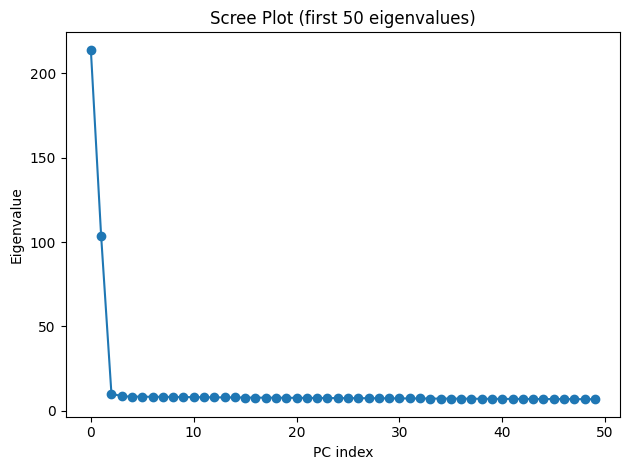

In [9]:
log("Plotting eigenvalues...")
plot_eigenvalues(eigvals, OUT_DIR / "eigenvalues.png")

7.b. Plot variance

Plotting cumulative variance...


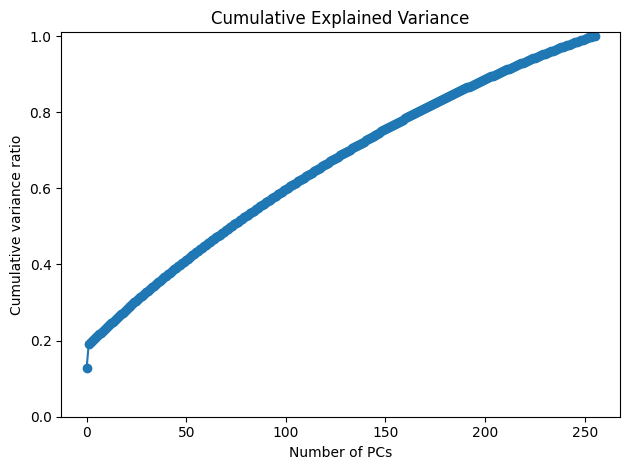

In [10]:
log("Plotting cumulative variance...")
plot_cumulative_variance(eigvals, OUT_DIR / "cumulative_variance.png")

8. Scatter with all SNPs

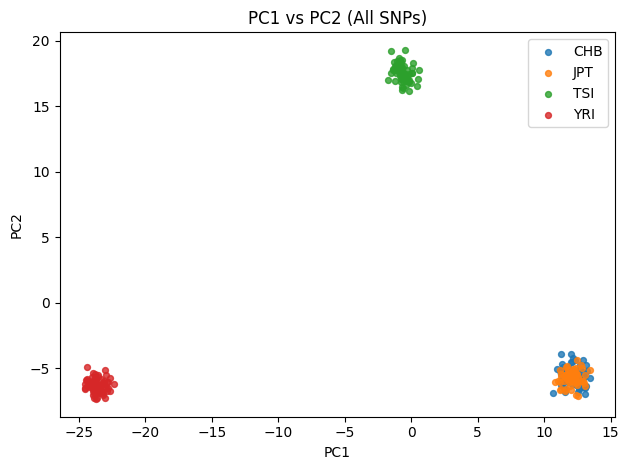

In [11]:
Z2 = Xc @ V[:, : K_STRUCTURE]
plot_pc_scatter(
    Z2, y_f, OUT_DIR / "pc_scatter_all_snps.png", title="PC1 vs PC2 (All SNPs)"
)

9. SNP Scoring and top SNP list

In [12]:
log(f"Scoring SNPs using top-k PCs (k={2})...")
scores_snps = pca_correlated_snp_scores(V, K_SCORE)
top_snps_df = select_top_snps(snp_names_f, scores_snps, top_k=2000)
top_snps_df.to_csv(OUT_DIR / "top_snps.csv", index=False)


Scoring SNPs using top-k PCs (k=2)...


10.a. Plot PCA using top-10 SNPs

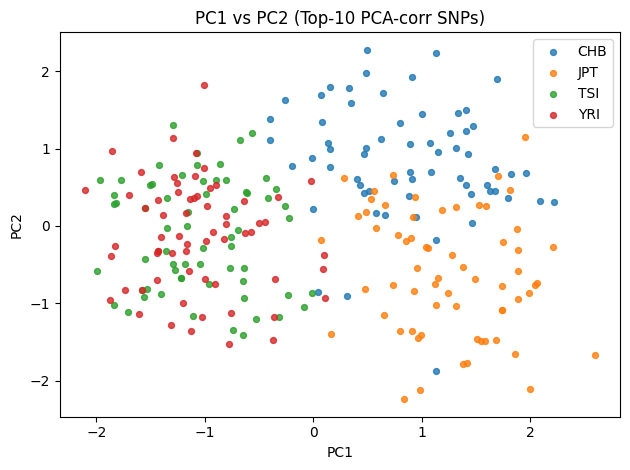

In [13]:
idx_top10 = np.argsort(-scores_snps)[:10]
Xp = Xc[:, idx_top10]
Xpc, _ = center_matrix(Xp)
eig_p, Vp_top10, _ = pca_svd(Xpc)
Zp_t10 = Xpc @ Vp_top10[:, :K_STRUCTURE]
plot_pc_scatter(
    Zp_t10, y_f, OUT_DIR / "pc_scatter_top_10.png", title="PC1 vs PC2 (Top-10 PCA-corr SNPs)"
)

10.b. Plot PCA using top-20 SNPs

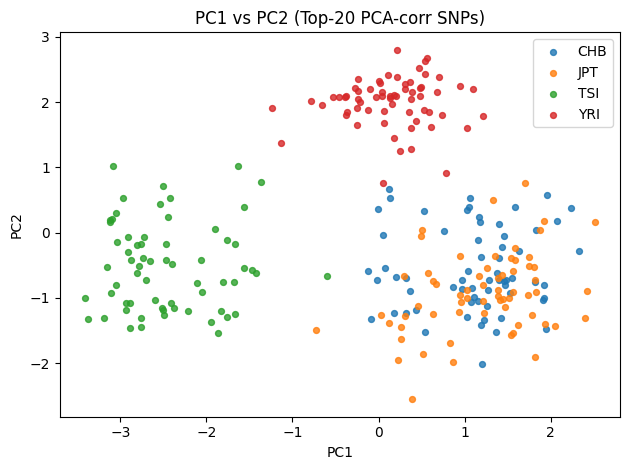

In [14]:
idx_top20 = np.argsort(-scores_snps)[:20]
Xp = Xc[:, idx_top20]
Xpc, mu_top20 = center_matrix(Xp)
eig_p, Vp_top20, _ = pca_svd(Xpc)
Zp_t20 = Xpc @ Vp_top20[:, :K_STRUCTURE]
plot_pc_scatter(
    Zp_t20, y_f, OUT_DIR / "pc_scatter_top_20.png", title="PC1 vs PC2 (Top-20 PCA-corr SNPs)"
)

10.c. Plot PCA using top-50 SNPs

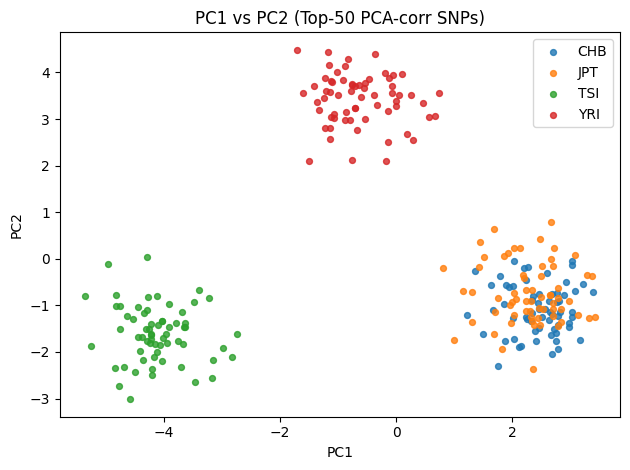

In [15]:
idx_top50 = np.argsort(-scores_snps)[:50]
Xp = Xc[:, idx_top50]
Xpc, _ = center_matrix(Xp)
eig_p, Vp_top50, _ = pca_svd(Xpc)
Zp_t50 = Xpc @ Vp_top50[:, :K_STRUCTURE]
plot_pc_scatter(
    Zp_t50, y_f, OUT_DIR / "pc_scatter_top_50.png", title="PC1 vs PC2 (Top-50 PCA-corr SNPs)"
)

10.d. Plot PCA using top 100 SNPs

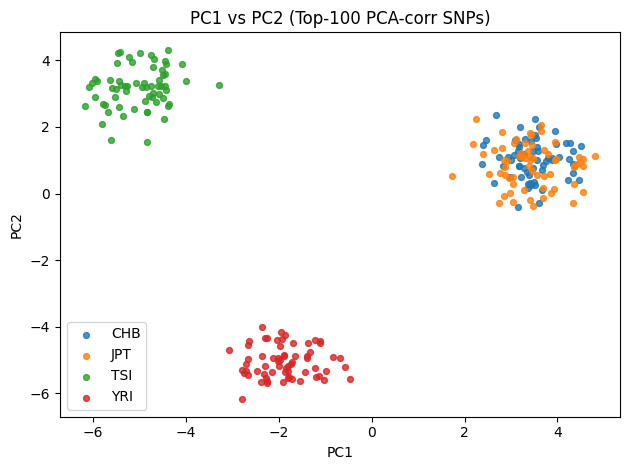

In [16]:
idx_top100 = np.argsort(-scores_snps)[:100]
Xp = Xc[:, idx_top100]
Xpc, _ = center_matrix(Xp)
eig_p, Vp_top100, _ = pca_svd(Xpc)
Zp_t100 = Xpc @ Vp_top100[:, :K_STRUCTURE]
plot_pc_scatter(
    Zp_t100, y_f, OUT_DIR / "pc_scatter_top_100.png", title="PC1 vs PC2 (Top-100 PCA-corr SNPs)"
)

10.e. Plot PCA using top-200 SNPs

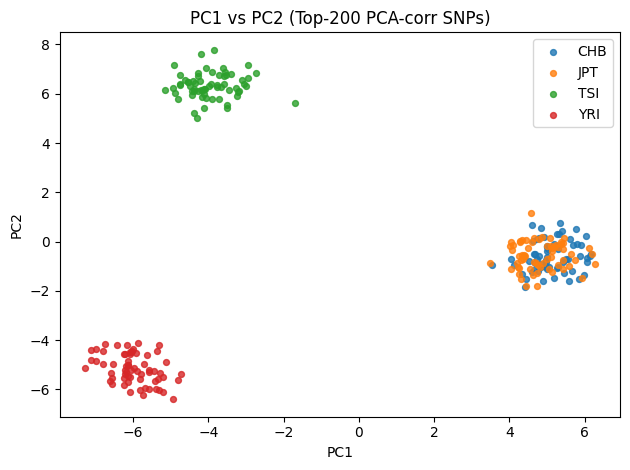

In [17]:
idx_top200 = np.argsort(-scores_snps)[:200]
Xp = Xc[:, idx_top200]
Xpc, _ = center_matrix(Xp)
eig_p, Vp_top200, _ = pca_svd(Xpc)
Zp_t200 = Xpc @ Vp_top200[:, :K_STRUCTURE]
plot_pc_scatter(
    Zp_t200, y_f, OUT_DIR / "pc_scatter_top_200.png", title="PC1 vs PC2 (Top-200 PCA-corr SNPs)"
)

11. Read the test data and prepare

In [18]:
log("Loading test data...")
X_te_df, y_te, iids_te, snp_cols_te = load_dataset(DATA_DIR, "genotypes_test.csv", "labels_test.csv")
log(f"Test: N={X_te_df.shape[0]} individuals, M={X_te_df.shape[1]} SNPs")

Loading test data...


Test: N=64 individuals, M=5000 SNPs


11.a. Select the same top-20 SNPs as training (order matters)

In [19]:
log("Selecting top-20 SNPs...")
top20_names = snp_names_f[idx_top20]
X_tr_20_df = X_df_f[top20_names]
X_te_20_df = X_te_df[top20_names]

Selecting top-20 SNPs...


11.b. Impute test with training SNP means

In [20]:
log("Imputing test data with training SNP means...")
X_tr_20_imp, X_te_20_imp = mean_impute_using_train(X_tr_20_df, X_te_20_df)

Imputing test data with training SNP means...


11.c. Center test with training mean (imputed 20-SNP train mean); project into training PCA space

In [21]:
log("Centering test data with training mean...")
train_mean_20 = X_tr_20_imp.to_numpy().mean(axis=0)
X_te_c = center_apply(X_te_20_imp.to_numpy(), train_mean_20)

log("Projecting into training PCA space...")
Z_te = X_te_c @ Vp_top20[:, :K_STRUCTURE]

Centering test data with training mean...
Projecting into training PCA space...


12. Plot train + test (test labels hidden for blind evaluation)

Plotting train + test...


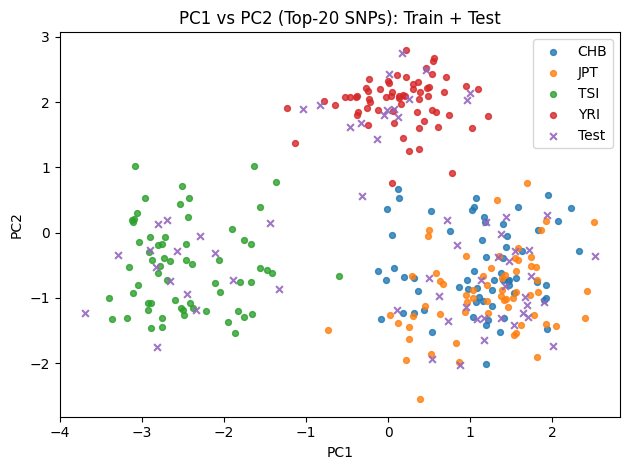

In [22]:
log("Plotting train + test...")
plot_pc_scatter_train_test(
    Zp_t20, y_f, Z_te, y_te,
    OUT_DIR / "pc_scatter_top20_train_test.png",
    title="PC1 vs PC2 (Top-20 SNPs): Train + Test",
    show_test_labels=False,
)

13. Apply K-NN to predict the labels of the test set.

Calculating accuracy...
k-NN (k=5) test accuracy: 0.7344
Calculating confusion matrix...


,CHB,JPT,TSI,YRI
CHB,7,9,0,0
JPT,7,9,0,0
TSI,0,0,16,0
YRI,1,0,0,15


Plotting confusion matrix...


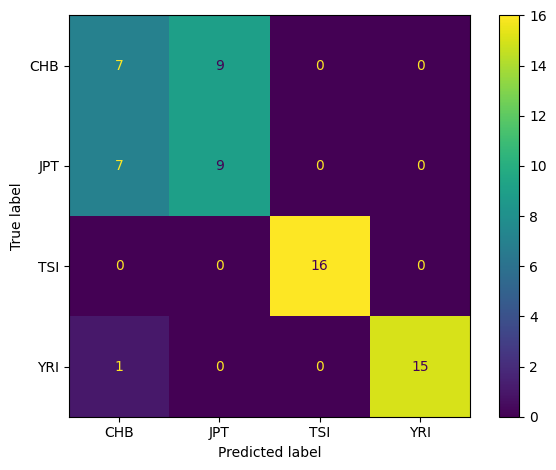

In [23]:
K_NN = 5
y_pred = knn_predict(Zp_t20, y_f, Z_te, k=K_NN)

# Accuracy
log("Calculating accuracy...")
accuracy = (y_pred == y_te).mean()
log(f"k-NN (k={K_NN}) test accuracy: {accuracy:.4f}")

# Confusion matrix (DataFrame)
log("Calculating confusion matrix...")
cm_df = confusion_matrix_df(y_te, y_pred)
display(cm_df)

# Confusion matrix plot
log("Plotting confusion matrix...")
plot_confusion_matrix(y_te, y_pred, OUT_DIR / "confusion_matrix.png")